## Preparación de entornos y datos (EJERCICIO 1)

### Importación de librerías

In [30]:
import warnings
# Google Colab en Python 3.12 muestra repetidamente este warning interno. Se oculta para que no sea molestoso
warnings.filterwarnings(
    "ignore",
    message=r"datetime\.datetime\.utcnow\(\) is deprecated.*",
    category=DeprecationWarning,
    module=r"jupyter_client\.session",
)

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from mlxtend.frequent_patterns import apriori, association_rules
from sklearn.cluster import KMeans
from sklearn.preprocessing import MinMaxScaler, StandardScaler


### Generar datos de ejemplo y guardárlos en un archivo CSV

In [31]:
n = 1000
np.random.seed(57)

datos = {
    "ID": range(1, n + 1),
    "Edad": np.random.randint(18, 81, n),
    "Ciudad": np.random.choice(
        ["Puerto Varas", "Puerto Montt", "Llanquihue", "Concepción", "Temuco"], n
    ),
    "HorasEjercicio": np.round(np.random.uniform(0, 10, n), 1),
    "IMC": np.round(np.random.uniform(15, 40, n), 1),
    "Fuma": np.random.choice(["Sí", "No"], n),
    "Consumo": np.random.choice(["Pescado", "Verduras", "Frutas"], n),
    "Consume_Fruta": np.random.choice([0, 1], n, p=[0.35, 0.65]),
    "Consume_Verdura": np.random.choice([0, 1], n, p=[0.30, 0.70]),
}

df = pd.DataFrame(datos)
df.to_csv("datos_salud.csv", index=False, encoding="utf-8")


## Manipulación de datos con Pandas (EJERCICIO 2)

In [32]:
df = pd.read_csv("datos_salud.csv")
print(df.head(n=10))

pacientes = df[(df["IMC"] > 30) & (df["HorasEjercicio"] < 2)]
print(pacientes)

promedio_imc_por_ciudad = df.groupby("Ciudad")["IMC"].mean()
print(promedio_imc_por_ciudad)

   ID  Edad        Ciudad  HorasEjercicio   IMC Fuma   Consumo  Consume_Fruta  \
0   1    33  Puerto Varas             6.3  34.5   Sí   Pescado              0   
1   2    40        Temuco             3.3  22.3   No    Frutas              1   
2   3    23        Temuco             2.8  35.5   No   Pescado              1   
3   4    40  Puerto Montt             5.5  26.4   No    Frutas              1   
4   5    33  Puerto Varas             8.7  27.9   Sí  Verduras              1   
5   6    74  Puerto Varas             5.0  36.3   No    Frutas              1   
6   7    52  Puerto Varas             8.7  35.3   No    Frutas              1   
7   8    74  Puerto Montt             2.0  23.2   No   Pescado              1   
8   9    58    Concepción             9.9  16.0   No    Frutas              0   
9  10    35    Concepción             4.3  29.8   No    Frutas              1   

   Consume_Verdura  
0                0  
1                1  
2                1  
3                0  
4  

## Operaciones con NumPy (EJERCICIO 3)

In [33]:
horas_ejercicio = df["HorasEjercicio"].to_numpy()
percentil_90 = np.percentile(horas_ejercicio, 90)
print("90º percentil de horas de ejercicio:", percentil_90)

minmax_scaler = MinMaxScaler()
datos_normalizados = minmax_scaler.fit_transform(df[["HorasEjercicio"]])

90º percentil de horas de ejercicio: 8.810000000000002


## Gráficos (EJERCICIO 4)

### Histograma de edades

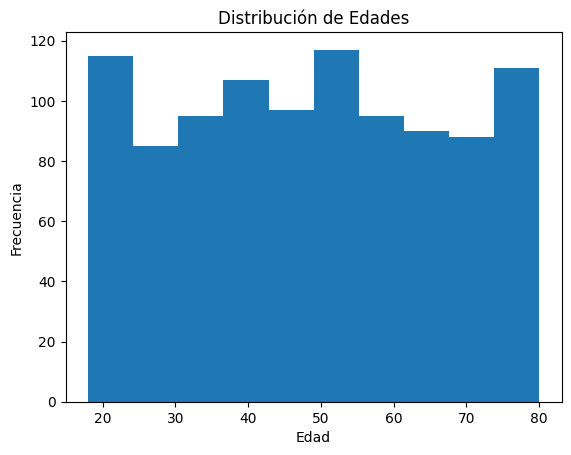

In [34]:
plt.hist(df["Edad"])
plt.title("Distribución de Edades")
plt.xlabel("Edad")
plt.ylabel("Frecuencia")
plt.show()

### Gráfico de dispersión entre IMC y horas de ejercicio

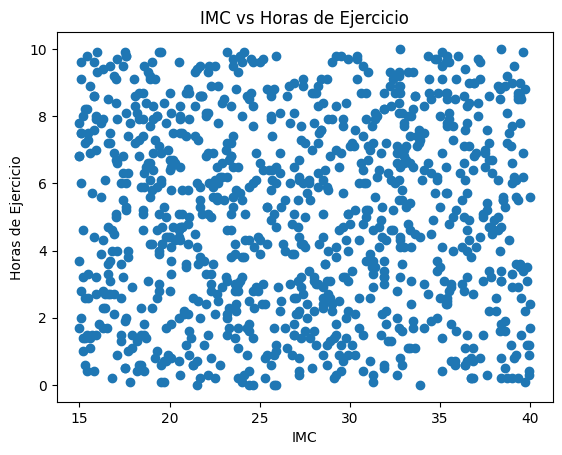

In [35]:
plt.scatter(x=df["IMC"], y=df["HorasEjercicio"])
plt.title("IMC vs Horas de Ejercicio")
plt.xlabel("IMC")
plt.ylabel("Horas de Ejercicio")
plt.show()

## Algoritmo Apriori (EJERCICIO 5)

In [36]:
datos_binarios = df[["Consume_Fruta", "Consume_Verdura"]].astype(bool)
itemsets = apriori(datos_binarios, min_support=0.1, use_colnames=True)
reglas = association_rules(itemsets, metric="confidence", min_threshold=0.5)
reglas.to_csv("reglas_asociacion.csv", index=False, encoding="utf-8")
print(reglas)

         antecedents        consequents  antecedent support  \
0    (Consume_Fruta)  (Consume_Verdura)               0.642   
1  (Consume_Verdura)    (Consume_Fruta)               0.688   

   consequent support  support  confidence      lift  representativity  \
0               0.688    0.443    0.690031  1.002952               1.0   
1               0.642    0.443    0.643895  1.002952               1.0   

   leverage  conviction  zhangs_metric   jaccard  certainty  kulczynski  
0  0.001304    1.006553       0.008222  0.499436   0.006510    0.666963  
1  0.001304    1.005322       0.009435  0.499436   0.005294    0.666963  


## Clustering con K-means (EJERCICIO 6)

### Cálculo de clusters

In [37]:
x = df[["Edad", "IMC", "HorasEjercicio"]]

scaler = StandardScaler()
x_escalado = scaler.fit_transform(x)

kmeans = KMeans(n_clusters=3, random_state=57)
clusters = kmeans.fit_predict(x_escalado)

df["Cluster"] = clusters
print("Número de personas por cluster:")
print(df["Cluster"].value_counts())

## 2. Interpretar los clusters usando promedios
promedios_cluster = df.groupby("Cluster")[["Edad", "IMC", "HorasEjercicio"]].mean()
print("Promedios por cluster:")
print(promedios_cluster)

for cluster, valores in promedios_cluster.iterrows():
    print(
        f"Cluster {cluster}: edad promedio {valores['Edad']:.2f}, "
        f"IMC promedio {valores['IMC']:.2f}, "
        f"horas de ejercicio promedio {valores['HorasEjercicio']:.2f}."
    )

centroids = scaler.inverse_transform(kmeans.cluster_centers_)


Número de personas por cluster:
Cluster
2    381
1    323
0    296
Name: count, dtype: int64
Promedios por cluster:
              Edad        IMC  HorasEjercicio
Cluster                                      
0        64.179054  24.311486        2.946622
1        35.702786  21.299381        5.975542
2        47.876640  34.379265        5.823360
Cluster 0: edad promedio 64.18, IMC promedio 24.31, horas de ejercicio promedio 2.95.
Cluster 1: edad promedio 35.70, IMC promedio 21.30, horas de ejercicio promedio 5.98.
Cluster 2: edad promedio 47.88, IMC promedio 34.38, horas de ejercicio promedio 5.82.


### Gráfico de los clusters en 3D

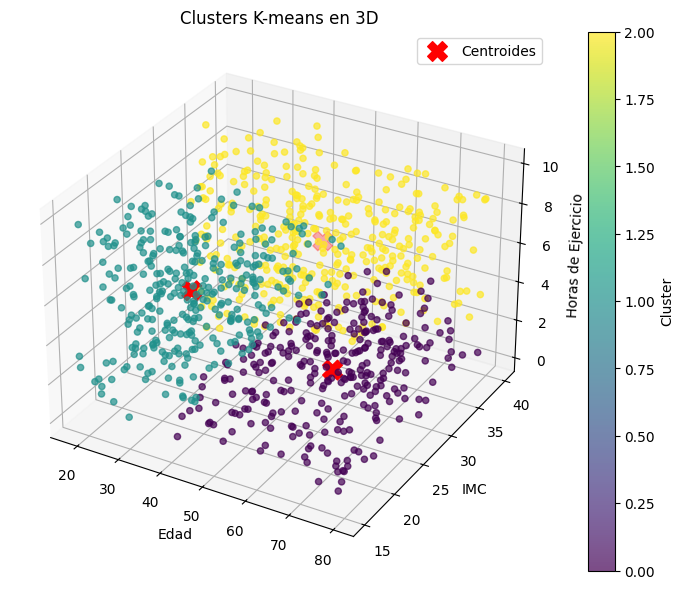

In [38]:
fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection="3d")

scatter = ax.scatter(
    df["Edad"],
    df["IMC"],
    df["HorasEjercicio"],
    c=df["Cluster"],
    cmap="viridis",
    alpha=0.7,
)

ax.scatter(
    centroids[:, 0],
    centroids[:, 1],
    centroids[:, 2],
    c="red",
    marker="X",
    s=200,
    label="Centroides",
)

ax.set_title("Clusters K-means en 3D")
ax.set_xlabel("Edad")
ax.set_ylabel("IMC")
ax.set_zlabel("Horas de Ejercicio")
fig.colorbar(scatter, ax=ax, label="Cluster")
ax.legend()

plt.show()